# Evidencia de los cálculos del informe

Este cuaderno **recomputa desde los datos geográficos originales** cada cifra que aparece en el
informe PEP2, de modo que ninguna quede como afirmación sin respaldo. No escribe nada: solo lee
`data/` y `data/results/`.


## Requisitos

Las dependencias están fijadas en `requirements.txt`, en la raíz del proyecto:

```bash
pip install -r requirements.txt
```

El cuaderno debe correr con el mismo intérprete donde quedaron instaladas. Si lanzas Jupyter
desde otro entorno, registra el del proyecto como kernel (una sola vez):

```bash
python -m pip install ipykernel
python -m ipykernel install --user --name solar --display-name "Python (proyecto solar)"
```

La celda siguiente localiza la raíz del proyecto por sí sola —sube directorios hasta encontrar
`config.yaml` y `src/`— así que funciona sin importar desde dónde abras el cuaderno, y aborta
con un mensaje claro si falta alguna dependencia.

In [1]:
# ---------------------------------------------------------------------------------
# Imports y preparación del entorno. Todo lo que el cuaderno necesita se declara aquí.
# ---------------------------------------------------------------------------------
import os, sys, json, importlib.util, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# La raíz se busca subiendo directorios hasta encontrar config.yaml y src/. Así el cuaderno
# funciona igual desde notebooks/, desde la raíz o desde donde se haya lanzado Jupyter.
def buscar_raiz(inicio=None):
    p = Path(inicio or Path.cwd()).resolve()
    for candidata in (p, *p.parents):
        if (candidata / 'config.yaml').exists() and (candidata / 'src').is_dir():
            return candidata
    raise RuntimeError('No se encontró la raíz del proyecto (config.yaml + src/). '
                       'Abre el cuaderno dentro del repositorio.')

RAIZ = buscar_raiz()
os.chdir(RAIZ)
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

# Dependencias de terceros: se comprueban antes de importar, para fallar con un mensaje
# accionable en vez de un ImportError suelto a mitad del cuaderno.
REQUERIDAS = ['numpy', 'pandas', 'yaml', 'rasterio', 'geopandas', 'matplotlib']
faltan = [m for m in REQUERIDAS if importlib.util.find_spec(m) is None]
if faltan:
    raise ImportError('Faltan dependencias: ' + ', '.join(faltan) +
                      '\nInstálalas con:  pip install -r requirements.txt')

import numpy as np
import pandas as pd
import yaml
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

# Funciones del proyecto. `shap` no se importa aquí porque solo lo necesita la celda
# opcional de la §5 y su carga es lenta.
from src.metricas_topk import (cargar_plantas, rasterizar_plantas,
                               _plantas_a_filas_columnas, calcular_metricas_topk,
                               KS_DEFECTO)

# ---------------------------------------------------------------------------------
# Configuración y constantes compartidas por el resto del cuaderno
# ---------------------------------------------------------------------------------
CONFIG  = yaml.safe_load(open('config.yaml', encoding='utf-8'))
DIR_COQ = CONFIG['transferibilidad']['dir_resultados']
CRS     = 'EPSG:32719'                               # UTM 19S, el CRS de todo el proyecto
HA_MW   = CONFIG['transferibilidad']['ha_por_mw']    # ocupación de suelo supuesta
NORTE   = CONFIG['zona_estudio']['regiones']
COQ     = CONFIG['transferibilidad']['regiones']

def leer_json(ruta):
    with open(ruta, encoding='utf-8') as f:
        return json.load(f)

print('Raíz del proyecto:', RAIZ)
print('Versiones (para reproducibilidad):')
for m in (np, pd, gpd, rasterio, plt.matplotlib):
    print(f'  {m.__name__:12s} {m.__version__}')

Raíz del proyecto: /home/braulinho/Desktop/GeoInformatica-Sitios-ptimos-para-Energ-a-Solar-en-el-Norte-de-Chile
Versiones (para reproducibilidad):
  numpy        2.5.2
  pandas       3.0.5
  geopandas    1.1.4
  rasterio     1.5.1
  matplotlib   3.11.1


## 1. Procedencia de los datos

Inventario de cada insumo con su CRS, resolución y número de entidades. Es la respuesta a
"¿de dónde salen estos datos?" antes de mirar ningún resultado.

In [2]:
filas = []
for nombre, ruta in CONFIG['paths']['raw']['vectores'].items():
    if not os.path.exists(ruta):
        continue
    g = gpd.read_file(ruta)
    filas.append({'insumo': nombre, 'tipo': 'vector', 'entidades': len(g),
                  'crs': str(g.crs), 'geometría': g.geom_type.iloc[0] if len(g) else '-'})

for nombre, ruta in [('GHI (procesado)', CONFIG['paths']['processed']['ghi_32719']),
                     ('DEM norte', CONFIG['paths']['processed']['dem_32719']),
                     ('slope norte', CONFIG['paths']['processed']['slope']),
                     ('DEM Coquimbo', CONFIG['transferibilidad']['dem']),
                     ('slope Coquimbo', CONFIG['transferibilidad']['slope'])]:
    if not os.path.exists(ruta):
        continue
    with rasterio.open(ruta) as r:
        filas.append({'insumo': nombre, 'tipo': 'ráster',
                      'entidades': f'{r.width * r.height:,} px',
                      'crs': str(r.crs), 'geometría': f'{r.res[0]:.0f} m'})

pd.DataFrame(filas)

,insumo,tipo,entidades,crs,geometría
0,regiones,vector,16,EPSG:5360,MultiPolygon
1,fotovoltaicas,vector,716,EPSG:9184,Point
2,lineas,vector,1127,EPSG:5360,LineString
3,almacenamiento,vector,91,EPSG:5360,Point
4,subestaciones,vector,1217,EPSG:5360,Point
5,areas_pobladas,vector,652,EPSG:3857,Polygon
6,masas_lacustres,vector,16475,EPSG:3857,Polygon
7,snap,vector,110,EPSG:5360,Polygon
8,GHI (procesado),ráster,"3,730,233 px",EPSG:32719,1097 m
9,DEM norte,ráster,"86,138,042 px",EPSG:32719,90 m


## 2. Reconstrucción de la huella

El catálogo de plantas es una capa de **puntos**: su área geométrica es exactamente cero, así
que la superficie ocupada hay que reconstruirla desde la potencia instalada. Esta celda
demuestra las tres afirmaciones del informe:

1. el área de los puntos es 0;
2. la cadena `potencia → área → radio → buffer` reproduce la huella teórica;
3. el rasterizado a 500 m se desvía poco de la huella vectorial.

In [3]:
def evidencia_huella(regiones, etiqueta):
    puntos  = cargar_plantas(CONFIG, str(RAIZ), CRS, regiones_estudio=regiones)
    buffers = cargar_plantas(CONFIG, str(RAIZ), CRS, ha_por_mw=HA_MW, regiones_estudio=regiones)
    pot = puntos['POTENCIAMW'].astype(float)
    return {
        'zona': etiqueta,
        'plantas': len(puntos),
        'potencia (MW)': round(pot.sum(), 1),
        'área de los puntos (m²)': puntos.geometry.area.sum(),
        'huella teórica (km²)': round(pot.sum() * HA_MW / 100, 2),
        'huella vectorial (km²)': round(buffers.geometry.area.sum() / 1e6, 2),
    }

pd.DataFrame([evidencia_huella(NORTE, 'Antofagasta+Atacama'),
              evidencia_huella(COQ, 'Coquimbo')]).set_index('zona').T

zona,Antofagasta+Atacama,Coquimbo
plantas,105.00,70.00
potencia (MW),7195.70,595.60
área de los puntos (m²),0.00,0.00
huella teórica (km²),143.91,11.91
huella vectorial (km²),143.68,11.89


In [4]:
# Casos trabajados: la cadena completa para la planta mayor, la mediana y la menor.
puntos = cargar_plantas(CONFIG, str(RAIZ), CRS, regiones_estudio=NORTE)
pot = puntos['POTENCIAMW'].astype(float)
sel = {'mayor': pot.idxmax(),
       'mediana': (pot - pot.median()).abs().idxmin(),
       'menor': pot[pot > 0].idxmin()}

filas = []
for etiqueta, i in sel.items():
    mw = float(pot.loc[i])
    area_m2 = mw * HA_MW * 10_000          # ha -> m²
    radio_m = np.sqrt(area_m2 / np.pi)     # despeje de A = pi r²
    filas.append({'caso': etiqueta,
                  'nombre': puntos.loc[i].get('NOMBRE', '-'),
                  'potencia (MW)': round(mw, 2),
                  'área (km²)': round(area_m2 / 1e6, 3),
                  'radio (m)': round(radio_m, 0),
                  'celdas de 500 m': round(area_m2 / 250_000, 1)})
pd.DataFrame(filas)

,caso,nombre,potencia (MW),área (km²),radio (m),celdas de 500 m
0,mayor,CEME 1,401.11,8.022,1598.0,32.1
1,mediana,ANDES SOLAR II B (AMPLIACION),27.30,0.546,417.0,2.2
2,menor,HORNITOS,0.32,0.006,45.0,0.0


## 3. El techo geométrico de la precisión

La precisión por área no puede superar la razón entre la huella y la superficie que el criterio
top-$K$ obliga a proponer. Ese techo es **propio de cada zona**, y por eso las precisiones
crudas no son comparables entre regiones: lo comparable es la fracción del techo alcanzada.

In [5]:
topk  = leer_json('data/results/metricas_topk.json')
transf = leer_json(f'{DIR_COQ}/metricas_transferibilidad.json')

filas = []
for etiqueta, bloque, area_km2 in [
        ('Antofagasta+Atacama', topk['out_of_sample_loro']['combinado_por_k']['1'], 202_826),
        ('Coquimbo', transf['metricas']['por_k']['1'], transf['metricas']['area_zona_km2'])]:
    pa = bloque['precision_area']
    techo = pa['precision_techo_modelo_perfecto']
    top_km2 = area_km2 * 0.01
    # El bloque combinado del norte no guarda la huella, pero el techo es por definición
    # huella / área del top-K, así que se despeja sin introducir ningún supuesto nuevo.
    huella = pa.get('area_huella_km2', round(techo * top_km2, 2))
    filas.append({'zona': etiqueta,
                  'área de la zona (km²)': round(area_km2),
                  'top 1 % (km²)': round(top_km2, 1),
                  'huella rasterizada (km²)': huella,
                  'techo = huella / top1% ': f"{100 * techo:.2f} %",
                  'precisión obtenida': f"{100 * pa['precision']:.3f} %",
                  '% del techo': f"{pa['pct_del_techo_alcanzado']:.1f} %"})
pd.DataFrame(filas).set_index('zona').T

zona,Antofagasta+Atacama,Coquimbo
área de la zona (km²),202826,40541
top 1 % (km²),2028.3,405.4
huella rasterizada (km²),144.48,9.75
techo = huella / top1%,7.12 %,2.40 %
precisión obtenida,5.287 %,0.678 %
% del techo,74.2 %,28.2 %


## 4. Recomputación independiente de Recall@K y Precisión@K

Esta es la celda de verificación. Se recalculan las métricas **desde el ráster entregado y la
capa de plantas**, sin leer el JSON, y recién después se contrastan contra él.

In [ ]:
with rasterio.open('data/results/mapa_probabilidad_aptitud.tif') as src:
    prob = src.read(1, masked=True)
    transform, crs_mapa = src.transform, src.crs
    forma = (src.height, src.width)
    area_px = abs(transform[0] * transform[4])

valido = ~np.ma.getmaskarray(prob) & np.isfinite(prob.filled(np.nan))
prob = prob.filled(np.nan)

pl   = cargar_plantas(CONFIG, str(RAIZ), crs_mapa, regiones_estudio=NORTE)
mask = rasterizar_plantas(pl, forma, transform)
rc   = _plantas_a_filas_columnas(pl, transform, forma)
buf  = rasterizar_plantas(cargar_plantas(CONFIG, str(RAIZ), crs_mapa,
                                         ha_por_mw=HA_MW, regiones_estudio=NORTE),
                          forma, transform)

recalc = calcular_metricas_topk(prob, valido, mask, rc, area_px, KS_DEFECTO, mask_buffer=buf)
guardado = topk['in_sample_mapa_entregado']

filas = []
for k in recalc['por_k']:
    a, b = recalc['por_k'][k], guardado['por_k'][k]
    filas.append({'K %': k,
                  'recall (recalculado)': a['recall'],
                  'recall (JSON)': b['recall'],
                  'precisión (recalc.)': a['precision_area']['precision'],
                  'precisión (JSON)': b['precision_area']['precision'],
                  'coincide': (a['recall'] == b['recall'] and
                               a['precision_area']['precision'] == b['precision_area']['precision'])})
tabla = pd.DataFrame(filas)
print('Píxeles válidos:', f"{recalc['n_pixeles_validos']:,}",
      '| plantas evaluadas:', recalc['n_plantas_evaluadas'])
tabla

Píxeles válidos: 20,184,890 | plantas evaluadas: 105
TODAS LAS CIFRAS COINCIDEN


,K %,recall (recalculado),recall (JSON),precisión (recalc.),precisión (JSON),coincide
0,0.5,0.6571,0.6571,0.098122,0.098122,True
1,1,0.8095,0.8095,0.058113,0.058113,True
2,2,0.9429,0.9429,0.032504,0.032504,True
3,3,1.0000,1.0000,0.022629,0.022629,True
4,5,1.0000,1.0000,0.014028,0.014028,True
5,7.5,1.0000,1.0000,0.009429,0.009429,True
6,10,1.0000,1.0000,0.007075,0.007075,True


## 5. Desplazamiento de covariables entre zonas

Explica **por qué** el modelo no transfiere. Un Random Forest no extrapola: fuera del rango de
valores visto en entrenamiento devuelve el valor de la hoja más cercana, de modo que una
variable desplazada no produce un error visible sino una predicción saturada en silencio.

> **Celda lenta (~2–4 min).** Reconstruye la grilla de variables de ambas zonas desde los
> rásters. Si solo quieres las cifras, la celda siguiente las lee del JSON.

In [7]:
shift = transf['covariate_shift']
filas = [{'variable': f,
          'entrenamiento (min–max)': f"{d['entrenamiento']['min']:g} – {d['entrenamiento']['max']:g}",
          'Coquimbo (min–max)': f"{d['zona']['min']:g} – {d['zona']['max']:g}",
          '% fuera de rango': d['pct_fuera_de_rango'],
          'desplazamiento (sd)': d['desplazamiento_medias_sd']}
         for f, d in sorted(shift.items(), key=lambda kv: -kv[1]['pct_fuera_de_rango'])]
tabla_shift = pd.DataFrame(filas)
tabla_shift

,variable,entrenamiento (min–max),Coquimbo (min–max),% fuera de rango,desplazamiento (sd)
0,slope,0.1505 – 17.0916,0.2556 – 47.3752,48.15,3.504
1,dist_transmision,4.7302 – 19923.5,0 – 60508.3,35.20,1.649
2,elev,19.7095 – 3491.82,3.7286 – 6109.97,15.74,0.182
3,dist_subestaciones,61.5337 – 41665,0 – 62018.1,6.57,0.897
4,ghi,196.616 – 304.575,169.967 – 283.998,3.48,-2.020
5,dist_almacen,239.8 – 229992,0 – 253886,1.88,1.195
6,northness,-1 – 1,-1 – 1,0.34,-0.195


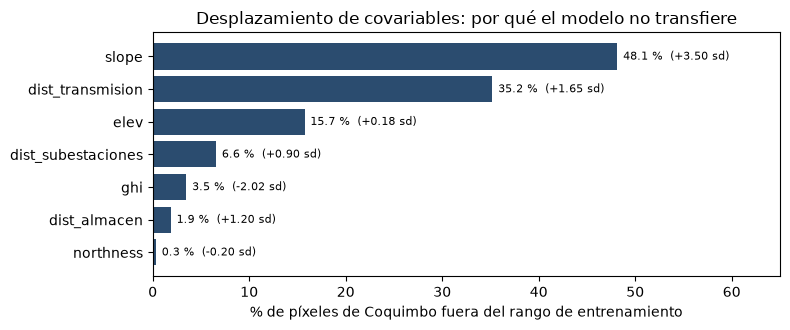

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.4))
t = tabla_shift.sort_values('% fuera de rango')
ax.barh(t['variable'], t['% fuera de rango'], color='#2B4C6F')
ax.set_xlabel('% de píxeles de Coquimbo fuera del rango de entrenamiento')
ax.set_title('Desplazamiento de covariables: por qué el modelo no transfiere')
for y, (v, s) in enumerate(zip(t['% fuera de rango'], t['desplazamiento (sd)'])):
    ax.text(v + 0.6, y, f'{v:.1f} %  ({s:+.2f} sd)', va='center', fontsize=8)
ax.set_xlim(0, max(t['% fuera de rango']) * 1.35)
plt.tight_layout()
fig.savefig('figures/coquimbo/desplazamiento_covariables.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# OPCIONAL Y LENTA: distribuciones reales desde los rásters, no desde el resumen del JSON.
EJECUTAR = False   # ponlo en True para reconstruir las grillas

if EJECUTAR:
    from src.explainability_spatial import _construir_features, zona_de_config
    from src.features import FEATURES
    from src.transferibilidad import cargar_muestras_entrenamiento

    _, _, _, _, _, X_coq = _construir_features(
        CONFIG, CONFIG['transferibilidad']['resolucion_m'],
        zona=zona_de_config(CONFIG, 'transferibilidad'))
    muestras = cargar_muestras_entrenamiento(CONFIG, str(RAIZ))

    fig, axes = plt.subplots(2, 4, figsize=(15, 6))
    for ax, (i, f) in zip(axes.ravel(), enumerate(FEATURES)):
        tr = muestras[f].astype(float).dropna().values
        zo = X_coq[:, i][np.isfinite(X_coq[:, i])]
        ax.hist(tr, bins=40, density=True, alpha=.6, label='entrenamiento')
        ax.hist(zo, bins=40, density=True, alpha=.6, label='Coquimbo')
        ax.axvline(tr.min(), ls='--', lw=.8, c='k'); ax.axvline(tr.max(), ls='--', lw=.8, c='k')
        ax.set_title(f, fontsize=9); ax.set_yticks([])
    axes.ravel()[0].legend(fontsize=8)
    axes.ravel()[-1].axis('off')
    plt.suptitle('Distribución por variable (líneas: rango visto en entrenamiento)')
    plt.tight_layout(); plt.show()
else:
    print('Celda desactivada. Cambia EJECUTAR = True para reconstruir las grillas.')

Celda desactivada. Cambia EJECUTAR = True para reconstruir las grillas.


## 6. Lo que sí transfiere: dominancia SHAP comparada

El desempeño cae, pero el criterio de decisión se conserva. Es la evidencia de que el modelo no
se desorienta, sino que se queda sin rango donde discriminar.

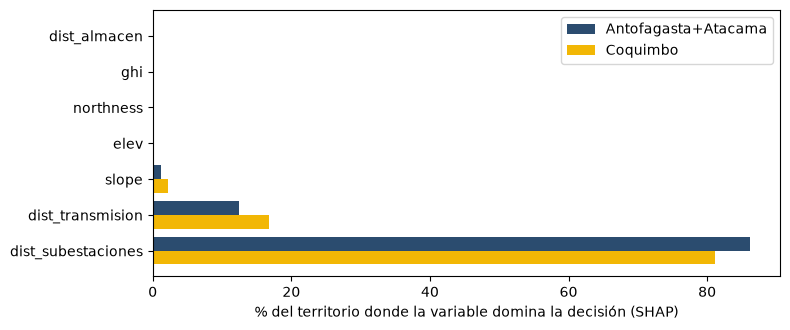

,variable,Antofagasta+Atacama (%),Coquimbo (%)
0,dist_subestaciones,86.20,81.11
1,dist_transmision,12.50,16.71
2,slope,1.22,2.17
3,elev,0.08,0.00
4,northness,0.00,0.00
5,ghi,0.00,0.01
6,dist_almacen,0.00,0.00


In [16]:
dom_n = leer_json('data/results/shap_espacial.json')['pixeles_por_variable_dominante']
dom_c = leer_json(f'{DIR_COQ}/shap_espacial.json')['pixeles_por_variable_dominante']
tn, tc = sum(dom_n.values()), sum(dom_c.values())

comp = pd.DataFrame([{'variable': f,
                      'Antofagasta+Atacama (%)': round(100 * dom_n.get(f, 0) / tn, 2),
                      'Coquimbo (%)': round(100 * dom_c.get(f, 0) / tc, 2)}
                     for f in sorted(dom_n, key=lambda x: -dom_n[x])])

fig, ax = plt.subplots(figsize=(8, 3.4))
y = np.arange(len(comp)); h = 0.38
ax.barh(y + h/2, comp['Antofagasta+Atacama (%)'], h, label='Antofagasta+Atacama', color='#2B4C6F')
ax.barh(y - h/2, comp['Coquimbo (%)'], h, label='Coquimbo', color='#F2B705')
ax.set_yticks(y); ax.set_yticklabels(comp['variable'])
ax.set_xlabel('% del territorio donde la variable domina la decisión (SHAP)')
ax.legend(); 
plt.tight_layout()
fig.savefig('figures/coquimbo/variables_SHAP.png', dpi=300, bbox_inches='tight')
plt.show()
comp